In [1]:
import pandas as pd

df_clean = pd.read_parquet('../data/curated/part1_taxi_curated.parquet')
df_clean.sample(5, random_state=42)


,PULocationID,DOLocationID,PU_borough,PU_zone,DO_borough,DO_zone,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_date,pickup_hour,...,trip_distance,fare_amount,tip_amount,total_amount,payment_type,trip_duration_min,speed_mph,fare_per_mile,tip_rate,distance_bucket
2409738,237,48,Manhattan,Upper East Side South,Manhattan,Clinton East,2023-01-26 22:42:40,2023-01-26 22:55:51,2023-01-26,22,...,2.10,14.2,3.84,23.04,1,13.183333,9.557522,6.761905,0.166667,"[1,3)"
1442295,170,161,Manhattan,Murray Hill,Manhattan,Midtown Center,2023-01-17 08:33:17,2023-01-17 08:42:16,2023-01-17,8,...,0.83,9.3,2.66,15.96,1,8.983333,5.543599,11.204819,0.166667,"[0,1)"
2803683,43,161,Manhattan,Central Park,Manhattan,Midtown Center,2023-01-31 09:26:42,2023-01-31 09:36:13,2023-01-31,9,...,1.87,11.4,0.00,15.40,2,9.516667,11.789842,6.096257,0.000000,"[1,3)"
1988338,148,114,Manhattan,Lower East Side,Manhattan,Greenwich Village South,2023-01-22 14:35:04,2023-01-22 14:48:41,2023-01-22,14,...,1.26,12.8,3.36,20.16,1,13.616667,5.552020,10.158730,0.166667,"[1,3)"
1052786,158,48,Manhattan,Meatpacking/West Village West,Manhattan,Clinton East,2023-01-13 00:20:57,2023-01-13 00:30:25,2023-01-13,0,...,2.69,13.5,1.00,19.50,1,9.466667,17.049296,5.018587,0.051282,"[1,3)"


In [2]:
df_clean.sort_values('pickup_date', ascending=True).head(10)

,PULocationID,DOLocationID,PU_borough,PU_zone,DO_borough,DO_zone,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_date,pickup_hour,...,trip_distance,fare_amount,tip_amount,total_amount,payment_type,trip_duration_min,speed_mph,fare_per_mile,tip_rate,distance_bucket
30398,1,1,EWR,Newark Airport,EWR,Newark Airport,2022-10-25 03:45:46,2022-10-25 03:45:50,2022-10-25,3,...,0.02,115.0,5.00,120.30,1,0.066667,18.000000,5750.000000,0.041563,"[0,1)"
62925,138,264,Queens,LaGuardia Airport,Unknown,NaN,2022-10-25 13:03:37,2022-10-25 13:03:40,2022-10-25,13,...,0.22,62.0,15.70,78.50,1,0.050000,264.000000,281.818182,0.200000,"[0,1)"
23399,132,132,Queens,JFK Airport,Queens,JFK Airport,2022-10-25 00:42:10,2022-10-25 00:44:22,2022-10-25,0,...,0.97,4.5,0.00,6.55,2,2.200000,26.454545,4.639175,0.000000,"[0,1)"
23400,265,265,NaN,Outside of NYC,NaN,Outside of NYC,2022-10-25 00:59:02,2022-10-25 01:09:02,2022-10-25,0,...,2.33,10.0,0.00,10.80,2,10.000000,13.980000,4.291845,0.000000,"[1,3)"
49549,132,38,Queens,JFK Airport,Queens,Cambria Heights,2022-10-25 09:06:23,2022-10-25 09:21:36,2022-10-25,9,...,6.48,19.5,0.00,21.55,2,15.216667,25.550931,3.009259,0.000000,"[5,10)"
45595,132,264,Queens,JFK Airport,Unknown,NaN,2022-10-25 07:48:15,2022-10-25 07:48:18,2022-10-25,7,...,0.76,78.0,15.76,94.56,1,0.050000,912.000000,102.631579,0.166667,"[0,1)"
2623,161,234,Manhattan,Midtown Center,Manhattan,Union Sq,2022-12-31 23:58:43,2023-01-01 00:09:39,2022-12-31,23,...,2.11,12.8,0.00,17.80,2,10.933333,11.579268,6.066351,0.000000,"[1,3)"
3198,132,48,Queens,JFK Airport,Manhattan,Clinton East,2022-12-31 23:58:59,2023-01-01 00:36:24,2022-12-31,23,...,22.02,70.0,40.00,121.80,1,37.416667,35.310468,3.178928,0.328407,"[10,+)"
3743,161,261,Manhattan,Midtown Center,Manhattan,World Trade Center,2022-12-31 23:59:40,2023-01-01 00:30:00,2022-12-31,23,...,6.87,37.3,0.00,42.30,2,30.333333,13.589011,5.429403,0.000000,"[5,10)"
2851,239,142,Manhattan,Upper West Side South,Manhattan,Lincoln Square East,2022-12-31 22:34:05,2022-12-31 22:40:07,2022-12-31,22,...,0.91,7.9,2.58,15.48,1,6.033333,9.049724,8.681319,0.166667,"[0,1)"


## A. Required groupby metrics.

### Non-trivial Statistics

**1. Daily trip counts grouped by PU_borough and pickup_date.**
   
   Grouping by `PU_borough` and `pickup_date` to get the number of trips per borough per day.


In [3]:
# 1. Daily trip counts grouped by PU_borough and pickup_date.
daily_trip_counts = (
    df_clean.groupby(['PU_borough', 'pickup_date'])
    .size()
    .reset_index(name='trip_count')
)

print(f"\n--- Daily Trip Counts --- {daily_trip_counts.shape}")
daily_trip_counts



--- Daily Trip Counts --- (216, 3)


,PU_borough,pickup_date,trip_count
0,Bronx,2023-01-01,91
1,Bronx,2023-01-02,61
2,Bronx,2023-01-03,122
3,Bronx,2023-01-04,165
4,Bronx,2023-01-05,140
...,...,...,...
211,Unknown,2023-01-27,1329
212,Unknown,2023-01-28,1204
213,Unknown,2023-01-29,1282
214,Unknown,2023-01-30,1089


In [67]:
daily_trip_counts.groupby("PU_borough").first()

,pickup_date,trip_count,rolling_7d_mean,dod_diff,dod_pct_change,weekday
PU_borough,,,,,,
Bronx,2023-01-01,91,91.0,-30.0,-0.329670,Sunday
Brooklyn,2023-01-01,687,687.0,-414.0,-0.602620,Sunday
EWR,2022-10-25,1,1.0,9.0,9.000000,Tuesday
Manhattan,2022-12-31,22,22.0,59304.0,2695.636364,Saturday
Queens,2022-10-25,4,4.0,-1.0,-0.250000,Tuesday
Staten Island,2023-01-01,6,6.0,2.0,0.333333,Sunday
Unknown,2023-01-01,1091,1091.0,-53.0,-0.048579,Sunday


In [22]:
(daily_trip_counts.groupby("PU_borough")["trip_count"].describe().round(2))

,count,mean,std,min,25%,50%,75%,max
PU_borough,,,,,,,,
Bronx,31.0,92.26,26.88,45.0,71.0,92.0,109.5,165.0
Brooklyn,31.0,427.42,94.14,253.0,381.0,401.0,466.0,687.0
EWR,25.0,3.08,1.96,1.0,2.0,3.0,4.0,10.0
Manhattan,33.0,77631.42,23586.20,8.0,69456.0,84680.0,93016.0,97852.0
Queens,34.0,7887.82,2757.42,2.0,7723.5,8405.0,9297.5,11185.0
Staten Island,31.0,8.29,2.53,3.0,7.0,8.0,10.5,12.0
Unknown,31.0,1208.13,122.70,980.0,1112.5,1204.0,1278.5,1466.0


**2. Mean and median of fare_amount and trip_distance grouped by PU_borough and weekday**
   
   Grouping by `PU_borough` and `weekday` to get the mean and median of fare_amount and trip_distance for each borough and weekday.


In [4]:
# 2. Mean and median of fare_amount and trip_distance grouped by PU_borough and weekday

fare_dist_stats = (
    df_clean.groupby(["PU_borough", "weekday"])[["fare_amount", "trip_distance"]]
    .agg(["mean", "median"])
    .reset_index()
    .round(4)
)

print(f"--- Fare and Distance Stats --- {fare_dist_stats.shape}")
fare_dist_stats.head()

--- Fare and Distance Stats --- (49, 6)


PU_borough weekday fare_amount        trip_distance       
                            mean median          mean median
0      Bronx     Fri     31.8469   26.2        7.2717   4.69
1      Bronx     Mon     31.4150   29.2        7.3752   5.70
2      Bronx     Sat     27.6058   22.5        6.6523   4.25
3      Bronx     Sun     26.8621   22.5        5.8563   4.40
4      Bronx     Thu     29.7251   25.4        6.8987   4.70

In [71]:
fare_dist_stats.groupby("PU_borough").max()

weekday fare_amount        trip_distance       
                             mean median          mean median
PU_borough                                                   
Bronx             Wed     32.2120   29.2        7.7363   5.74
Brooklyn          Wed     27.2446   23.3        5.5806   3.90
EWR               Wed     98.2781  103.0       18.1967  21.00
Manhattan         Wed     15.3064   12.1        2.8403   1.79
Queens            Wed     53.0036   54.8       13.3420  12.52
Staten Island     Wed     61.7854   65.2       16.1779  19.15
Unknown           Wed     30.1014   23.3       14.3529   4.28

**3. For each pickup_hour, the proportion of trips by payment_type**

The `normalize=True` argument ensures that the proportions are calculated as a percentage of the total number of trips for that pickup_hour.

In [5]:
# 3. For each pickup_hour, the proportion of trips by payment_type
payment_type_props = (
    df_clean.groupby("pickup_hour")["payment_type"]
    .value_counts(normalize=True)
    .reset_index(name="proportion")
    .round(4)
)

print(f"\n--- Payment Type Proportions --- {payment_type_props.shape}")
payment_type_props.head()


--- Payment Type Proportions --- (96, 3)


,pickup_hour,payment_type,proportion
0,0,1,0.8300
1,0,2,0.1575
2,0,4,0.0083
3,0,3,0.0043
4,1,1,0.8419


**4. Mean tip_rate grouped by distance_bucket**

In [6]:
# 4. Mean tip_rate grouped by distance_bucket
mean_tip_rate_by_distance = (
    df_clean.groupby("distance_bucket")["tip_rate"]
    .mean()
    .reset_index(name="mean_tip_rate")
    .round(4)
)

print(f"\n--- Mean Tip Rate by Distance Bucket --- {mean_tip_rate_by_distance.shape}")
mean_tip_rate_by_distance


--- Mean Tip Rate by Distance Bucket --- (5, 2)


,distance_bucket,mean_tip_rate
0,"[0,1)",0.1191
1,"[1,3)",0.1237
2,"[3,5)",0.1205
3,"[5,10)",0.1128
4,"[10,+)",0.1110


## B. Required window-style metrics.

In [7]:
daily_trip_counts = daily_trip_counts.sort_values(
    by=["PU_borough", "pickup_date"]
).reset_index(drop=True)

daily_trip_counts

,PU_borough,pickup_date,trip_count
0,Bronx,2023-01-01,91
1,Bronx,2023-01-02,61
2,Bronx,2023-01-03,122
3,Bronx,2023-01-04,165
4,Bronx,2023-01-05,140
...,...,...,...
211,Unknown,2023-01-27,1329
212,Unknown,2023-01-28,1204
213,Unknown,2023-01-29,1282
214,Unknown,2023-01-30,1089


**1. For each PU_borough, a 7-day rolling mean of daily trip counts ordered by pickup_date**

The `rolling(window=7, min_periods=1)` argument specifies a window of 7 days and a minimum of 1 day required to calculate the rolling mean. This allows for the calculation of the rolling mean even when there are fewer than 7 days of data available such as at the first few days. 

In [60]:
# 1. For each PU_borough, a 7-day rolling mean of daily trip counts ordered by pickup_date
daily_trip_counts["rolling_7d_mean"] = (
    daily_trip_counts
    .sort_values(by='pickup_date', ascending=True)
    .groupby("PU_borough")["trip_count"]
    .transform(lambda x: x.rolling(window=7, min_periods=1)
    .mean()
    .round(4)
))

daily_trip_counts

,PU_borough,pickup_date,trip_count,rolling_7d_mean,dod_diff,dod_pct_change,weekday
0,Bronx,2023-01-01,91,91.0000,NaN,NaN,Sunday
1,Bronx,2023-01-02,61,76.0000,-30.0,-0.329670,Monday
2,Bronx,2023-01-03,122,91.3333,61.0,1.000000,Tuesday
3,Bronx,2023-01-04,165,109.7500,43.0,0.352459,Wednesday
4,Bronx,2023-01-05,140,115.8000,-25.0,-0.151515,Thursday
...,...,...,...,...,...,...,...
211,Unknown,2023-01-27,1329,1165.4286,54.0,0.042353,Friday
212,Unknown,2023-01-28,1204,1171.1429,-125.0,-0.094056,Saturday
213,Unknown,2023-01-29,1282,1175.4286,78.0,0.064784,Sunday
214,Unknown,2023-01-30,1089,1180.5714,-193.0,-0.150546,Monday


In [72]:
daily_trip_counts.groupby("PU_borough").apply(
    lambda x: x
    .describe()
    .drop(index=['25%', '50%', '75%', 'std'])
    .round(2)
)

pickup_date  trip_count  rolling_7d_mean  \
PU_borough                                                              
Bronx         count                   31       31.00            31.00   
              mean   2023-01-16 00:00:00       92.26            92.42   
              min    2023-01-01 00:00:00       45.00            76.00   
              max    2023-01-31 00:00:00      165.00           115.80   
Brooklyn      count                   31       31.00            31.00   
              mean   2023-01-16 00:00:00      427.42           434.91   
              min    2023-01-01 00:00:00      253.00           365.71   
              max    2023-01-31 00:00:00      687.00           687.00   
EWR           count                   25       25.00            25.00   
              mean   2023-01-11 09:36:00        3.08             3.30   
              min    2022-10-25 00:00:00        1.00             1.00   
              max    2023-01-31 00:00:00       10.00             5.50   
Manhattan     count                   33       33.00            33.00   
              mean   2023-01-16 00:00:00    77631.42         74932.94   
              min    2022-12-31 00:00:00        8.00            22.00   
              max    2023-02-01 00:00:00    97852.00         88474.43   
Queens        count                   34       34.00            34.00   
              mean   2023-01-13 13:24:42     7887.82          7594.87   
              min    2022-10-25 00:00:00        2.00             3.50   
              max    2023-02-01 00:00:00    11185.00          9472.86   
Staten Island count                   31       31.00            31.00   
              mean   2023-01-16 00:00:00        8.29             8.24   
              min    2023-01-01 00:00:00        3.00             6.00   
              max    2023-01-31 00:00:00       12.00            10.43   
Unknown       count                   31       31.00            31.00   
              mean   2023-01-16 00:00:00     1208.13          1192.60   
              min    2023-01-01 00:00:00      980.00          1064.50   
              max    2023-01-31 00:00:00     1466.00          1323.57   

                     dod_diff  dod_pct_change  
PU_borough                                     
Bronx         count     30.00           30.00  
              mean       0.67            0.07  
              min      -44.00           -0.41  
              max       61.00            1.09  
Brooklyn      count     30.00           30.00  
              mean     -10.17            0.01  
              min     -414.00           -0.60  
              max      176.00            0.43  
EWR           count     24.00           24.00  
              mean       0.04            0.69  
              min       -6.00           -0.80  
              max        9.00            9.00  
Manhattan     count     32.00           32.00  
              mean      -0.44           84.23  
              min   -85351.00           -1.00  
              max    59304.00         2695.64  
Queens        count     33.00           33.00  
              mean      -0.06           88.76  
              min    -7221.00           -1.00  
              max     8790.00         2930.00  
Staten Island count     30.00           30.00  
              mean      -0.10            0.06  
              min       -8.00           -0.73  
              max        6.00            1.20  
Unknown       count     30.00           30.00  
              mean      10.13            0.01  
              min     -199.00           -0.16  
              max      306.00            0.28

**2. For each PU_borough, the day-over-day difference and day-over-day percent change**

The `diff()` and `pct_change()` methods are used to calculate the day-over-day difference and day-over-day percent change respectively.


In [9]:
# 2. For each PU_borough, the day-over-day difference and day-over-day percent change
daily_trip_counts["dod_diff"] = (daily_trip_counts
    .groupby("PU_borough")["trip_count"]
    .diff()
)


daily_trip_counts["dod_pct_change"] = (daily_trip_counts
    .groupby("PU_borough")["trip_count"]
    .pct_change()
)

daily_trip_counts

,PU_borough,pickup_date,trip_count,rolling_7d_mean,dod_diff,dod_pct_change
0,Bronx,2023-01-01,91,91.0000,NaN,NaN
1,Bronx,2023-01-02,61,76.0000,-30.0,-0.329670
2,Bronx,2023-01-03,122,91.3333,61.0,1.000000
3,Bronx,2023-01-04,165,109.7500,43.0,0.352459
4,Bronx,2023-01-05,140,115.8000,-25.0,-0.151515
...,...,...,...,...,...,...
211,Unknown,2023-01-27,1329,1165.4286,54.0,0.042353
212,Unknown,2023-01-28,1204,1171.1429,-125.0,-0.094056
213,Unknown,2023-01-29,1282,1175.4286,78.0,0.064784
214,Unknown,2023-01-30,1089,1180.5714,-193.0,-0.150546


## C. Required EDA questions (answer all three with evidence).

1. Which borough has the strongest weekday effect? Quantify it using:

$$
S_{borough} = \frac{\max({\mu_{\text{weekday,borough}}})-{\min({\mu_{\text{weekday,borough}}})}}{\mu_{\text{borough}}}
$$

where $S_{\text{borough}}$ is the measure of weekday effect , µweekday, borough is mean daily trips for that weekday in the borough and µweekday, borough is mean daily trips for the borough.

In [10]:
# mean daily trips per (borough, weekday)
# first add weekday column to daily_trip_counts
daily_trip_counts['weekday'] = pd.to_datetime(daily_trip_counts['pickup_date']).dt.day_name()

mu_weekday = (
    daily_trip_counts
    .groupby(['PU_borough', 'weekday'])['trip_count']
    .mean()
    .reset_index(name='mu_weekday')
)

# overall mean daily trips per borough
mu_borough = (
    daily_trip_counts
    .groupby('PU_borough')['trip_count']
    .mean()
    .reset_index(name='mu_borough')
)

# S_borough = (max weekday mean - min weekday mean) / overall mean
s_df = (
    mu_weekday
    .groupby('PU_borough')['mu_weekday']
    .agg(max_mu='max', min_mu='min')
    .reset_index()
    .merge(mu_borough, on='PU_borough') 
)
s_df['S_borough'] = (s_df['max_mu'] - s_df['min_mu']) / s_df['mu_borough'] #calculate weekday effect score for each borough

print('---Weekday Effect S_borough per borough ---')
print(s_df.sort_values('S_borough', ascending=False).to_string(index=False))

---Weekday Effect S_borough per borough ---
   PU_borough   max_mu  min_mu   mu_borough  S_borough
          EWR     4.20     1.5     3.080000   0.876623
        Bronx   121.50    62.8    92.258065   0.636259
       Queens  9611.20  5688.4  7887.823529   0.497323
     Brooklyn   538.75   326.4   427.419355   0.496819
    Manhattan 93265.00 64964.2 77631.424242   0.364553
Staten Island     9.50     7.2     8.290323   0.277432
      Unknown  1329.00  1073.4  1208.129032   0.211567


### C2. Identify two specific dates with anomalous total trip volume using a z-score on daily totals.
### Show the z-scores and the two selected dates.


In [11]:
# daily total trips across  boroughs
daily_total = (
    daily_trip_counts
    .groupby('pickup_date')['trip_count']
    .sum()
    .reset_index(name='total_trips')
)

daily_total['pickup_date'] = pd.to_datetime(daily_total['pickup_date'])

 
daily_total_ = daily_total[
    (daily_total['pickup_date'].dt.year == 2023) &
    (daily_total['pickup_date'].dt.month == 1)
].copy()

# compute z-score
mu  = daily_total_['total_trips'].mean()
sig = daily_total_['total_trips'].std()
daily_total_['z_score'] = ((daily_total_['total_trips'] - mu) / sig).round(4)

print(daily_total_.sort_values('z_score').to_string(index=False))

# two most anomalous dates
daily_total_['abs_z'] = daily_total_['z_score'].abs()
anomalies = daily_total_.nlargest(2, 'abs_z')
print('\n--- Two most anomalous dates ---')
print(anomalies[['pickup_date', 'total_trips', 'z_score']].to_string(index=False))

pickup_date  total_trips  z_score
 2023-01-02        61878  -2.5501
 2023-01-01        70004  -1.8849
 2023-01-16        75501  -1.4349
 2023-01-30        78646  -1.1774
 2023-01-09        80076  -1.0603
 2023-01-08        80167  -1.0529
 2023-01-03        80561  -1.0206
 2023-01-29        82848  -0.8334
 2023-01-23        84242  -0.7193
 2023-01-22        84243  -0.7192
 2023-01-04        89522  -0.2870
 2023-01-15        91120  -0.1562
 2023-01-10        94322   0.1059
 2023-01-31        94475   0.1184
 2023-01-17        95092   0.1689
 2023-01-05        95188   0.1768
 2023-01-06        96629   0.2948
 2023-01-24        97906   0.3993
 2023-01-07        99189   0.5043
 2023-01-18       100151   0.5831
 2023-01-11       100173   0.5849
 2023-01-25       102145   0.7463
 2023-01-20       103197   0.8324
 2023-01-13       104124   0.9083
 2023-01-12       104470   0.9367
 2023-01-28       105147   0.9921
 2023-01-27       105199   0.9963
 2023-01-21       105665   1.0345
 2023-01-14   

### Determine whether tip_rate is more strongly associated with pickup_hour or distance_bucket.
### Use a quantitative comparison and report your conclusion.

In [12]:

# higher = stronger association

clean_tips = df_clean[df_clean['tip_rate'].notna()].copy() # keep rows with no null tip_rate for this analysis

def eta_squared(groups, values):
    grand_mean = values.mean()
    ss_between = sum(
        len(values[groups == g]) * (values[groups == g].mean() - grand_mean) ** 2 #sum of squares between groups
        for g in groups.unique()
    )
    ss_total = ((values - grand_mean) ** 2).sum() #total sum of squares
    return ss_between / ss_total if ss_total > 0 else 0

eta2_hour   = eta_squared(clean_tips['pickup_hour'].astype(str),     clean_tips['tip_rate']) #convert to string to treat as categorical
eta2_bucket = eta_squared(clean_tips['distance_bucket'].astype(str), clean_tips['tip_rate'])

print(f'---Association with tip_rate ---')
print(f'pickup_hour    : {eta2_hour}') #output full precision for comparison
print(f'distance_bucket : {eta2_bucket}')

winner = 'pickup_hour' if eta2_hour > eta2_bucket else 'distance_bucket' #to determine  the stronger association with tip_rate
print(f'\ntip_rate is more strongly associated with: {winner}')

---Association with tip_rate ---
pickup_hour    : 0.002523806798073822
distance_bucket : 0.0031987954729942847

tip_rate is more strongly associated with: distance_bucket


## D.Visualizations

**Import libraries**

In [13]:
#import libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

### D1. Time Series of Daily Trips per Borough with 7-Day Rolling Average Overlaid

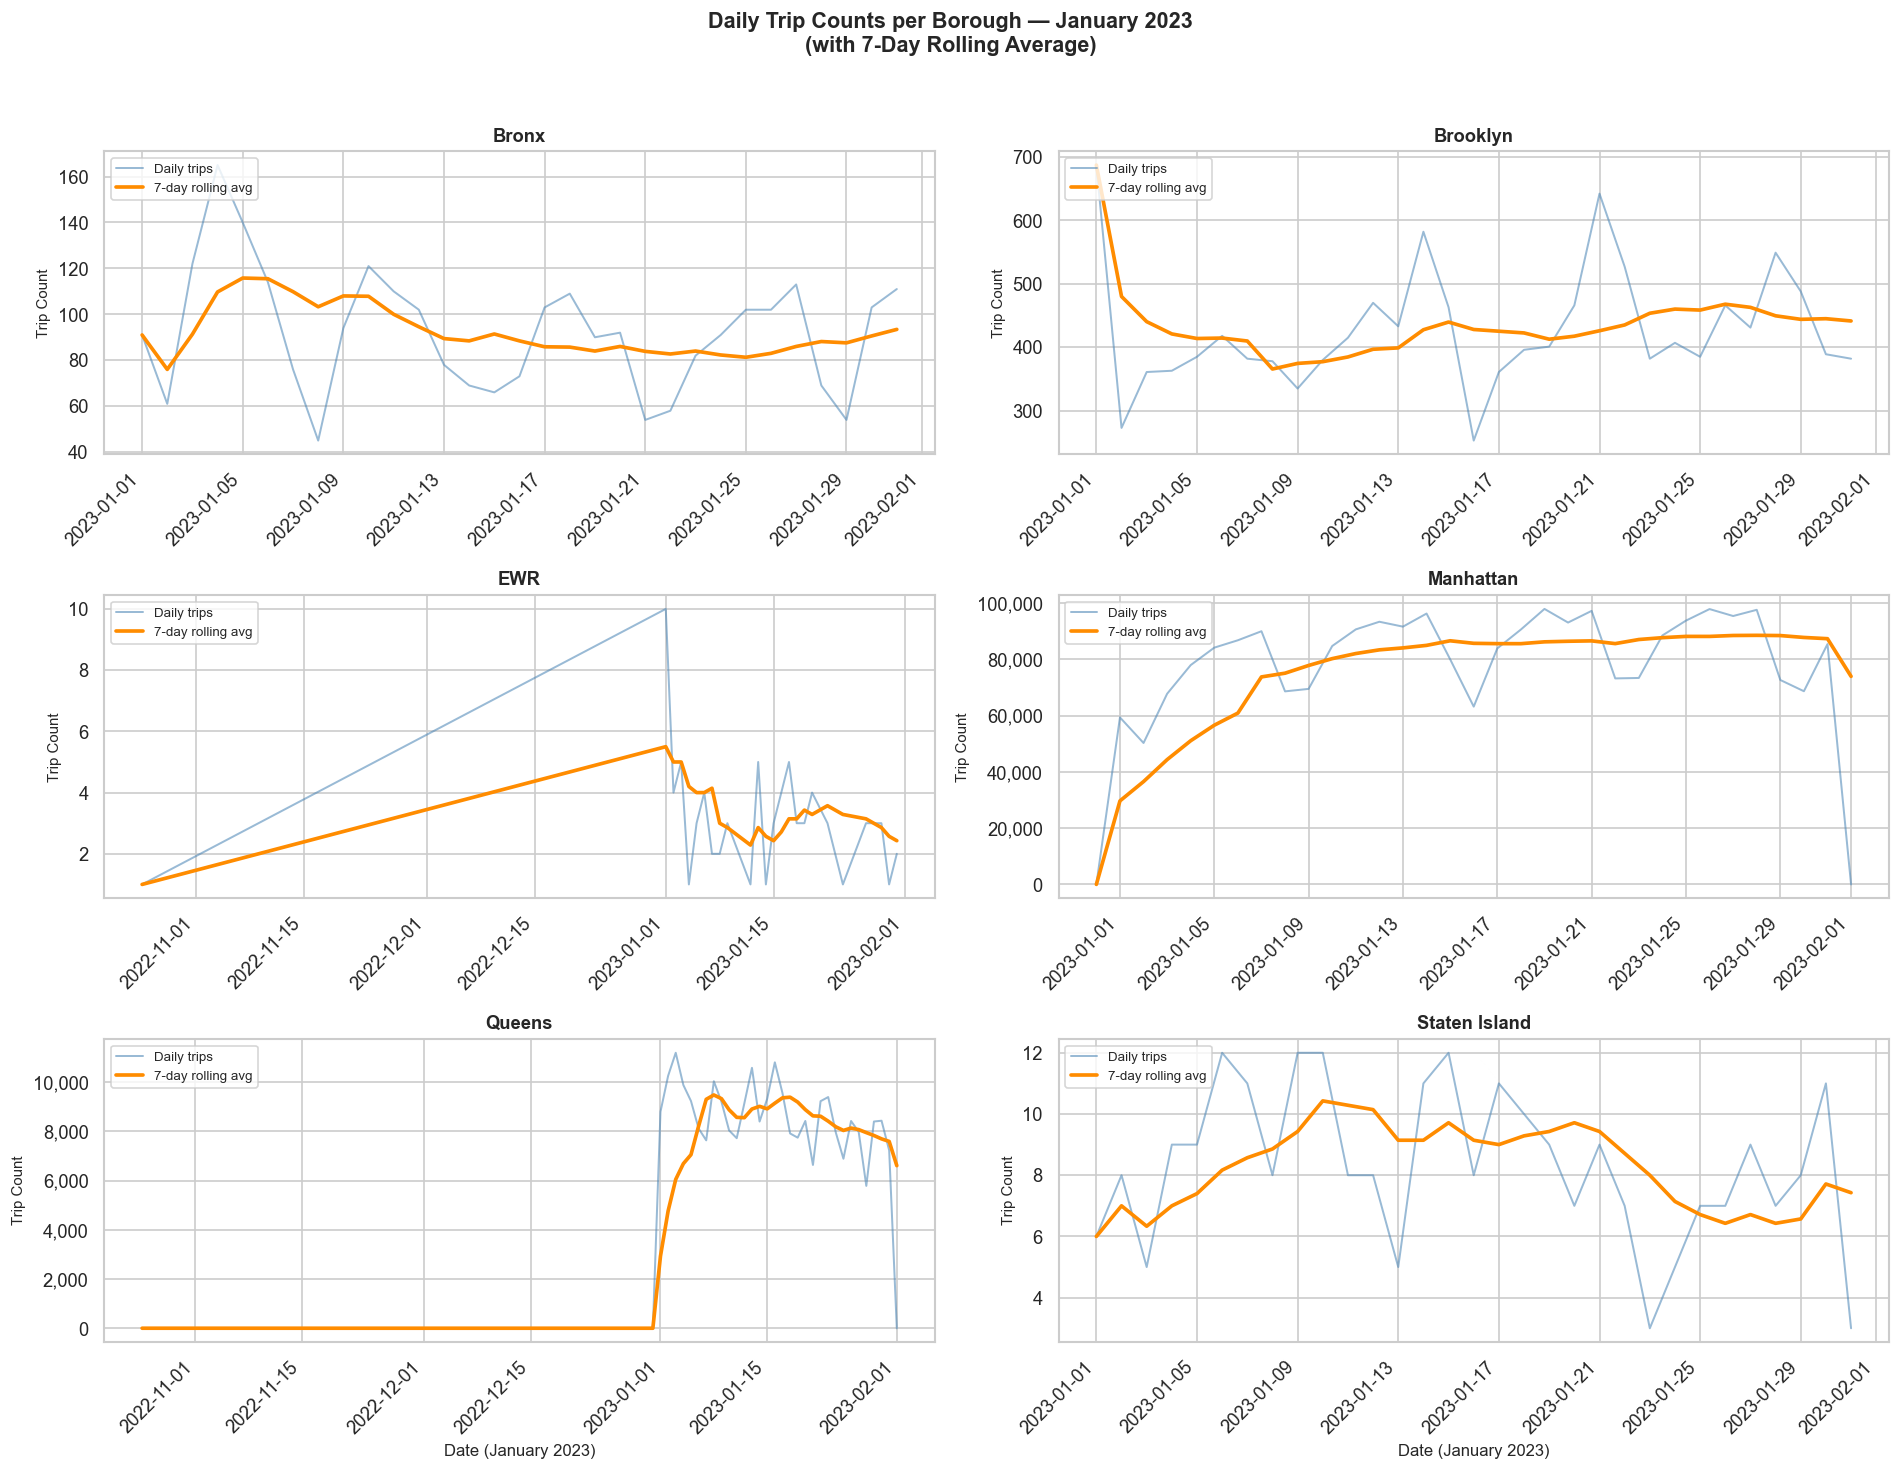

In [14]:
# D1: Time series of daily trips for each borough with rolling 7-day average overlaid

daily_trip_counts["pickup_date"] = pd.to_datetime(daily_trip_counts["pickup_date"])

# disregard 'Unknown' borough for clarity
boroughs = [b for b in daily_trip_counts["PU_borough"].unique() if b != "Unknown"]

# 3x2 grid for up to 6 boroughs
n_boros = len(boroughs)
ncols = 2
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12), sharex=False)
axes = axes.flatten()

for ax, borough in zip(axes, boroughs):
    subset = daily_trip_counts[daily_trip_counts["PU_borough"] == borough].sort_values(
        "pickup_date"
    )
    ax.plot(
        subset["pickup_date"],
        subset["trip_count"],
        alpha=0.55,
        linewidth=1.2,
        label="Daily trips",
        color="steelblue",
    )
    ax.plot(
        subset["pickup_date"],
        subset["rolling_7d_mean"],
        linewidth=2.2,
        label="7-day rolling avg",
        color="darkorange",
    )
    ax.set_title(borough, fontsize=11, fontweight="bold")
    ax.set_ylabel("Trip Count", fontsize=9)
    # Rotate the date labels on the x-axis by 45 degrees
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(fontsize=8, loc="upper left")

# Hide unused subplots if any
for idx in range(len(boroughs), len(axes)):
    axes[idx].axis("off")

# Set xlabel only on bottom row subplots
for idx in range(n_boros):
    if idx >= (nrows - 1) * ncols:
        axes[idx].set_xlabel("Date (January 2023)", fontsize=10)

fig.suptitle(
    "Daily Trip Counts per Borough — January 2023\n(with 7-Day Rolling Average)",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("../part1_taxi/plot1_daily_trips_borough.png", bbox_inches="tight")
plt.show()

### D2. Before/After Cleaning Distribution of `trip_duration_min`

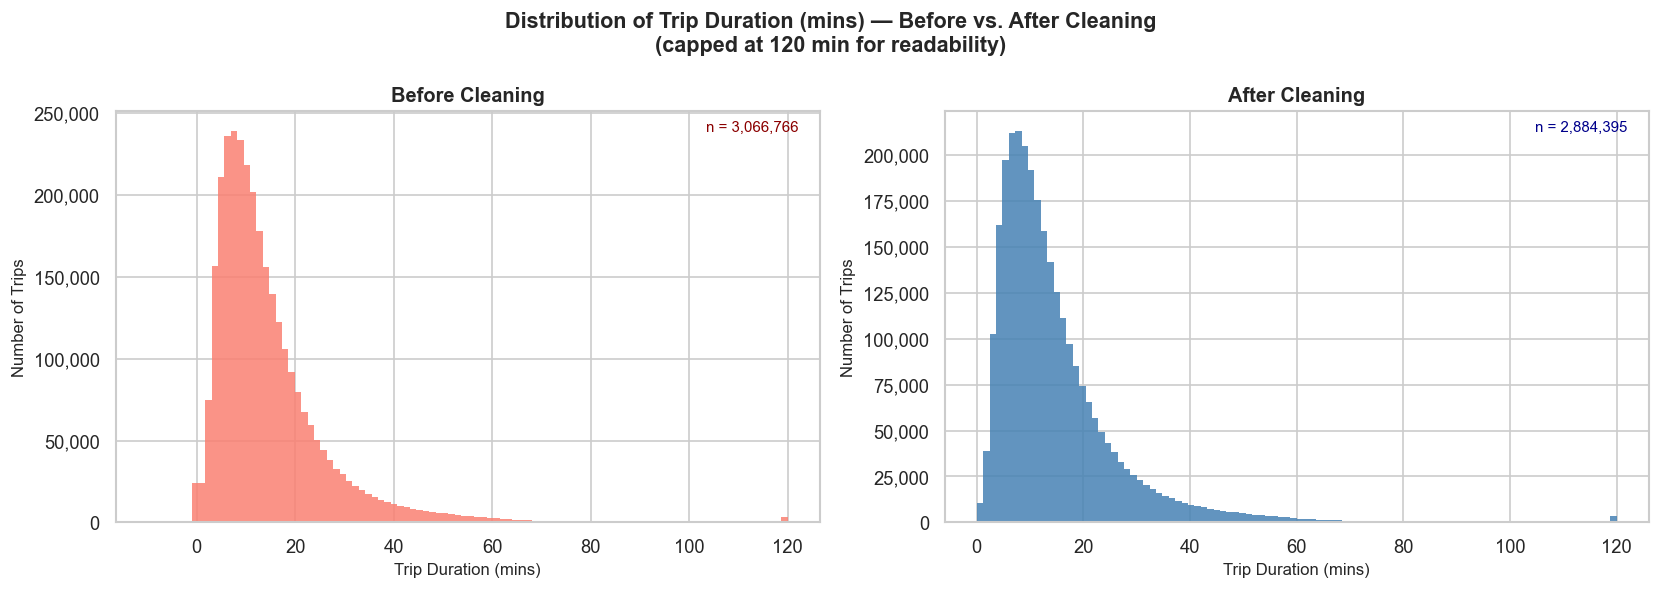

In [15]:
# D2: Before/after cleaning distribution of trip_duration_min

import pyarrow as pa
for ext_name in ['pandas.interval', 'pandas.period']:
    try:
        pa.unregister_extension_type(ext_name)
    except KeyError:
        pass

# load raw data and compute trip_duration_min before cleaning
df_raw = pd.read_parquet('../data/raw/tlc/yellow_tripdata_2023-01.parquet', engine='fastparquet')
df_raw['tpep_pickup_datetime']  = pd.to_datetime(df_raw['tpep_pickup_datetime'])
df_raw['tpep_dropoff_datetime'] = pd.to_datetime(df_raw['tpep_dropoff_datetime'])
df_raw['trip_duration_min'] = (
    (df_raw['tpep_dropoff_datetime'] - df_raw['tpep_pickup_datetime']).dt.total_seconds() / 60.0
)

# clip to a readable range for the histogram (0–120 min)
clip_max = 120
before_clipped = df_raw['trip_duration_min'].clip(lower=-10, upper=clip_max).dropna()
after_clipped  = df_clean['trip_duration_min'].clip(upper=clip_max)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].hist(before_clipped, bins=100, color='salmon', edgecolor='none', alpha=0.85)
axes[0].set_title('Before Cleaning', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trip Duration (mins)', fontsize=10)
axes[0].set_ylabel('Number of Trips', fontsize=10)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].annotate(f'n = {len(df_raw):,}', xy=(0.97, 0.95), xycoords='axes fraction',
                  ha='right', fontsize=9, color='darkred')

axes[1].hist(after_clipped, bins=100, color='steelblue', edgecolor='none', alpha=0.85)
axes[1].set_title('After Cleaning', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Trip Duration (mins)', fontsize=10)
axes[1].set_ylabel('Number of Trips', fontsize=10)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].annotate(f'n = {len(df_clean):,}', xy=(0.97, 0.95), xycoords='axes fraction',
                  ha='right', fontsize=9, color='darkblue')

fig.suptitle('Distribution of Trip Duration (mins) — Before vs. After Cleaning\n'
             '(capped at 120 min for readability)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../part1_taxi/plot2_trip_duration_before_after.png', bbox_inches='tight')
plt.show()

### D3. Relationship Plot: `trip_distance` vs `fare_amount`

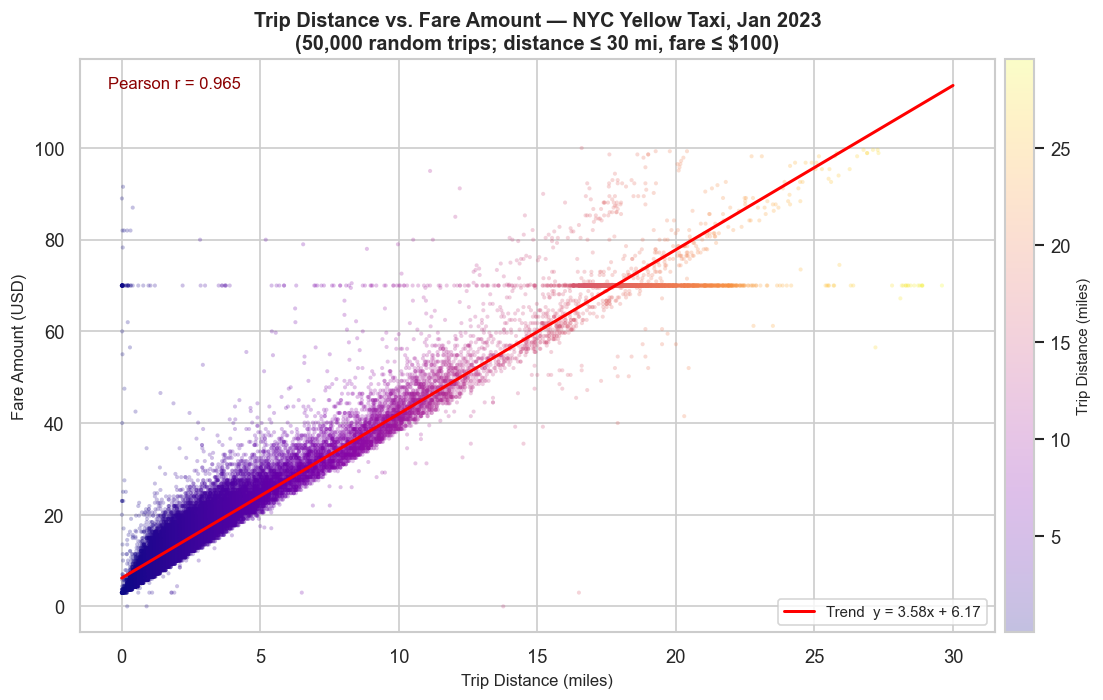

In [16]:
# D3: Relationship plot: trip_distance vs fare_amount
# sample 50k points to keep the scatter readable

sample = df_clean[
    (df_clean['trip_distance'] <= 30) &
    (df_clean['fare_amount']   <= 100)
].sample(n=50_000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    sample['trip_distance'],
    sample['fare_amount'],
    c=sample['trip_distance'],
    cmap='plasma',
    alpha=0.25,
    s=6,
    linewidths=0
)

# add a linear trend line
m, b = np.polyfit(sample['trip_distance'], sample['fare_amount'], 1)
x_line = np.linspace(0, 30, 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.8, label=f'Trend  y = {m:.2f}x + {b:.2f}')

# correlation annotations
corr = sample['trip_distance'].corr(sample['fare_amount'])
ax.annotate(f'Pearson r = {corr:.3f}', xy=(0.03, 0.95), xycoords='axes fraction',
             fontsize=10, color='darkred')

cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label('Trip Distance (miles)', fontsize=9)

ax.set_title('Trip Distance vs. Fare Amount — NYC Yellow Taxi, Jan 2023\n'
             '(50,000 random trips; distance ≤ 30 mi, fare ≤ $100)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Trip Distance (miles)', fontsize=10)
ax.set_ylabel('Fare Amount (USD)', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../part1_taxi/plot3_distance_vs_fare.png', bbox_inches='tight')
plt.show()

### D4. Heatmap of Average Trips by Weekday (rows) and Pickup Hour (columns)

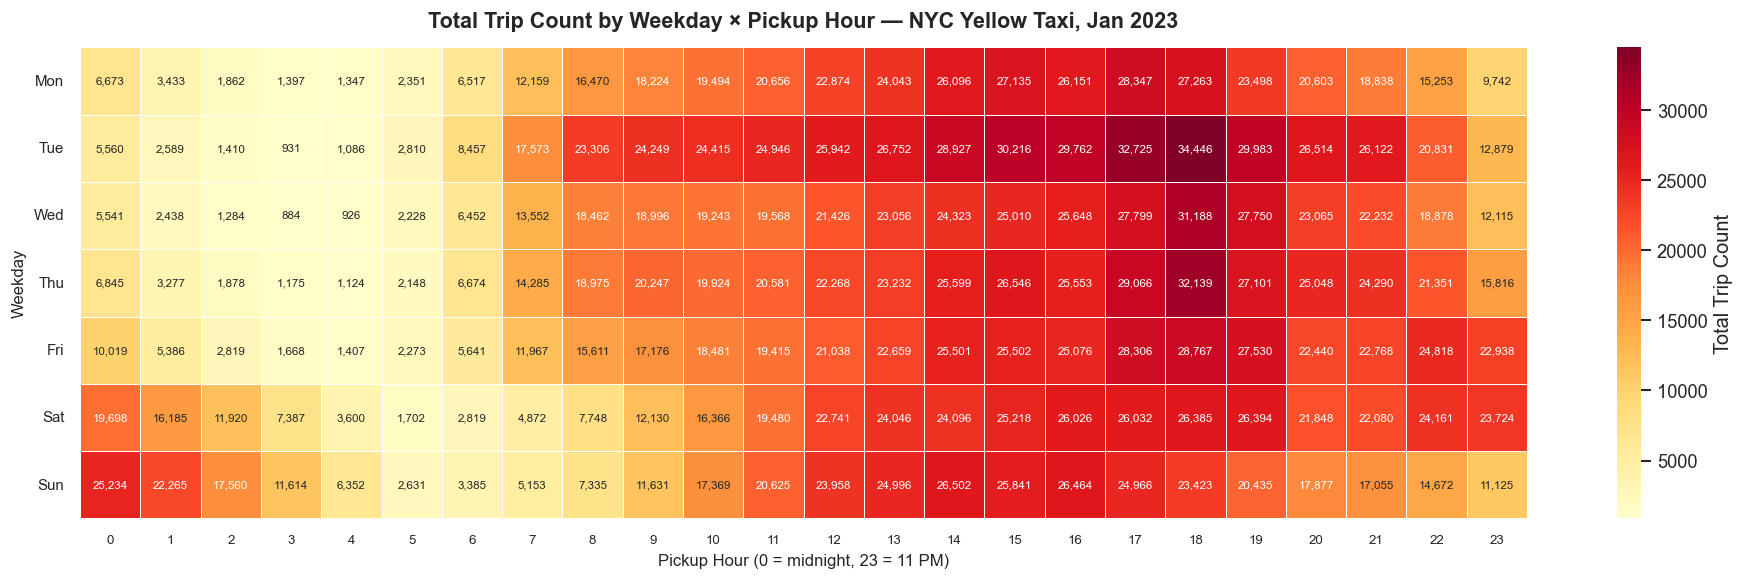

In [17]:
# D4: Heatmap of average trips by weekday (rows) and pickup_hour (columns)

# order weekday labels from Mon -> Sun
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# MEAN trip count per (weekday, pickup_hour)
heatmap_data = (
    df_clean
    .groupby(['weekday', 'pickup_hour'])
    .size()
    .reset_index(name='trip_count')
)

heatmap_pivot = heatmap_data.pivot(index='weekday', columns='pickup_hour', values='trip_count')
heatmap_pivot = heatmap_pivot.reindex(weekday_order)  # order rows Mon-Sun

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap='YlOrRd',
    fmt=',d',
    linewidths=0.3,
    linecolor='white',
    annot=True,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Total Trip Count'}
)

ax.set_title('Total Trip Count by Weekday × Pickup Hour — NYC Yellow Taxi, Jan 2023',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Pickup Hour (0 = midnight, 23 = 11 PM)', fontsize=10)
ax.set_ylabel('Weekday', fontsize=10)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig('../part1_taxi/plot4_heatmap_weekday_hour.png', bbox_inches='tight')
plt.show()